# Dark Pattern Analyzer -- Stage 1: Fine-tuning

Multilingual multi-label dark pattern classifier for **English, Hindi and Nepali**.

| | |
|---|---|
| Runtime | GPU (a free T4 is sufficient) |
| Expected time | 30-50 minutes end to end |
| Output | `model_v1.zip` -- the artifact bundle for Stage 2 |

### Sections

| # | What | Skippable? |
|---|---|---|
| 1 | Setup and dataset validation | No |
| 2 | **Tokenizer fertility** -- decides the base model | **No** |
| 3 | Baseline (TF-IDF + logistic regression) | No -- it is your floor |
| 4 | Fine-tune the transformer | No |
| 5 | Per-class threshold tuning | No -- free 3-6 F1 points |
| 6 | Evaluation | No |
| 7 | ONNX export + int8 quantization | No |
| 8 | **Parity test** | **No** |
| 9 | Bundle and download | No |

> **Before you start:** `Runtime > Change runtime type > T4 GPU`

---

### Two decisions this notebook makes on evidence rather than assumption

**Section 2 picks your base model.** Nepali is under-represented in multilingual
pretraining corpora. If mDistilBERT shreds Nepali words into fragments, MuRIL --
pretrained on Nepali explicitly -- becomes the primary model. Ten minutes of
measurement beats a guess you discover was wrong after a full training run.

**Section 8 decides whether the exported model is trustworthy.** int8 quantization
sometimes collapses a single class while raising no error at all. Without the parity
test you would find out during your demonstration, or never.

---
## 1. Setup and dataset validation

In [1]:
# Confirm the GPU is attached. If this reports no GPU, fix the runtime first --
# CPU training takes hours instead of minutes.
import subprocess
try:
    out = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'])
    print(out.decode().strip())
except Exception:
    print('No GPU detected. Runtime > Change runtime type > T4 GPU')

Tesla T4, 15360 MiB


In [4]:
# Clone the repository. Replace with your own URL.
REPO_URL = 'https://github.com/ArbinSama2004/dark-pattern-analyzer.git'


import os
if not os.path.exists('/content/dark-pattern-analyzer'):
    !git clone -q $REPO_URL /content/dark-pattern-analyzer

%cd /content/dark-pattern-analyzer/ml
!cd /content/dark-pattern-analyzer && git pull
!ls

/content/dark-pattern-analyzer/ml
Already up to date.
artifacts  notebooks  pyproject.toml  README.md  reports  src  uv.lock


In [8]:
# Mount Drive for checkpoints.
#
# Do this. Colab disconnects, and it tends to happen 40 minutes into a run.
# Checkpointing to Drive means a disconnect costs you minutes rather than the
# whole session.
from google.colab import drive
drive.mount('/content/drive')

import pathlib
CKPT = pathlib.Path('/content/drive/MyDrive/dp_checkpoints')
CKPT.mkdir(parents=True, exist_ok=True)
print('checkpoints ->', CKPT)

Mounted at /content/drive
checkpoints -> /content/drive/MyDrive/dp_checkpoints


In [9]:
# Colab already ships torch. Install only what is missing, and avoid pinning
# aggressively -- fighting Colab's preinstalled versions costs more time than it
# saves.
!pip install -q 'transformers>=4.44' 'datasets>=2.21' 'accelerate>=0.34' \
               'onnx>=1.16' 'onnxruntime>=1.19' 'scikit-learn>=1.5'

import sys
sys.path.insert(0, '/content/dark-pattern-analyzer/ml/src')

import torch, transformers
print('torch       ', torch.__version__)
print('transformers', transformers.__version__)
print('cuda        ', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 76.1 MB/s eta 0:00:00
torch        2.11.0+cu128
transformers 5.13.1
cuda         True


In [10]:
# Validate the dataset BEFORE anything expensive runs.
#
# This asserts template disjointness across train/val/test. It is the most
# important check in the project: the data is template-generated, so if one
# template appears on both sides of a split, the model can score 0.98 by
# memorising skeletons and the number is meaningless.
from ml.dataset import load_all_parts, describe

# DATA = '/content/dark-pattern-analyzer/data/synthetic'
DATA = '/content/dark-pattern-analyzer/data/synthetic_v2'
parts = load_all_parts(DATA)          # raises on leakage
print(describe(parts))

NOTE: dropped 17 evaluation row(s) whose exact text also appears in an earlier part (val: 4, test: 13).
      Cause: two different templates rendered an identical short string. Templates remain disjoint; this keeps evaluation clean.
      Example: 'अस्वीकार गर्नुहोस्'

=== train: 17,427 rows, 590 templates
  per language: en=5783, hi=5596, ne=6048
  label positives:
    confirmshaming    1,771
    false_urgency     2,145
    forced_action     1,847
    obstruction       1,804
    scarcity          2,338
    sneaking          1,791
    social_proof      1,909
    benign            4,354
  multi-label rows: 532 (3.1%)

=== val: 4,634 rows, 149 templates
  per language: en=1613, hi=1494, ne=1527
  label positives:
    confirmshaming      476
    false_urgency       343
    forced_action       473
    obstruction         421
    scarcity            463
    sneaking            505
    social_proof        550
    benign            1,403
  multi-label rows: 0 (0.0%)

=== test: 6,405 rows, 181

---
## 2. Tokenizer fertility -- choosing the base model

**Do not skip this.** It runs in a few minutes and it can change what you train.

**Fertility** = subword tokens produced per whitespace word. A tokenizer barely
exposed to Nepali during pretraining shatters Nepali words into fragments, so the
model sees noise instead of morphemes and burns sequence length doing it.

**Decision rule:** if mDistilBERT's Nepali fertility exceeds roughly 1.5x MuRIL's,
switch the primary model to MuRIL and keep mDistilBERT as a documented comparison.

Record the table either way. Nepali tokenizer coverage is a genuine finding about
low-resource NLP and it belongs in your report.

In [11]:
from ml.tokenizer_fertility import analyse, recommend

fert = analyse(DATA, sample_per_lang=600)
print(recommend(fert))

fert.pivot(index='model_key', columns='lang', values='fertility')


--- mdistilbert: distilbert-base-multilingual-cased


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

    en: fertility=1.394  unk=0.0000%
    hi: fertility=1.558  unk=0.0000%
    ne: fertility=1.706  unk=0.0000%

Fertility (subword tokens per word, lower is better)
lang            en     hi     ne
model_key                       
mdistilbert  1.491  2.205  2.904
minilm       1.394  1.558  1.706
muril        1.292  1.315  1.516
xlmr         1.394  1.558  1.706

Lowest Nepali fertility: muril (1.516)
mDistilBERT / MuRIL Nepali fertility ratio: 1.92x

>>> RECOMMENDATION: use google/muril-base-cased as PRIMARY.
    mDistilBERT fragments Nepali substantially worse. Keep it as a
    documented comparison in your report -- the gap is a finding.

Nepali-to-English fertility ratio (script disadvantage):
    mdistilbert: 1.95x
    minilm: 1.22x
    muril: 1.17x
    xlmr: 1.22x


Max p95 token length across all models/languages: 34
    max_length=64 is sufficient.


lang,en,hi,ne
model_key,,,
mdistilbert,1.491,2.205,2.904
minilm,1.394,1.558,1.706
muril,1.292,1.315,1.516
xlmr,1.394,1.558,1.706


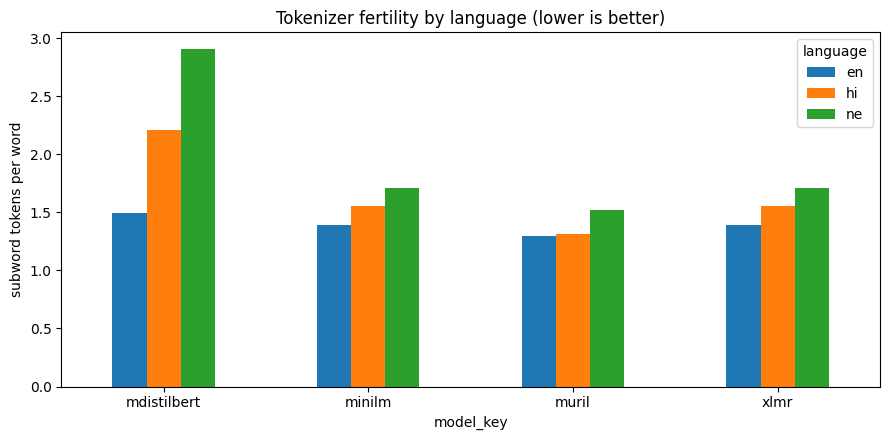

In [12]:
# Chart it -- this goes straight into your report.
import matplotlib.pyplot as plt

pivot = fert.pivot(index='model_key', columns='lang', values='fertility')
ax = pivot.plot(kind='bar', figsize=(9, 4.5), rot=0)
ax.set_ylabel('subword tokens per word')
ax.set_title('Tokenizer fertility by language (lower is better)')
ax.legend(title='language')
plt.tight_layout(); plt.show()

In [13]:
# ==> SET YOUR CHOICE HERE, based on the output above.
#
#   'mdistilbert'  distilbert-base-multilingual-cased   (default)
#   'muril'        google/muril-base-cased              (if Nepali fertility is poor)
#   'xlmr'         xlm-roberta-base                     (upper-bound reference)
#   'minilm'       Multilingual-MiniLM-L12-H384         (smallest)
MODEL_KEY = 'muril'

from ml.config import CANDIDATE_MODELS
print('Training:', CANDIDATE_MODELS[MODEL_KEY])
print()
print('Write your reason down now, while the numbers are in front of you.')
print('It belongs in docs/RESULTS.md and in your report.')

Training: google/muril-base-cased

Write your reason down now, while the numbers are in front of you.
It belongs in docs/RESULTS.md and in your report.


---
## 3. Baseline -- TF-IDF character n-grams + logistic regression

Without a baseline, a macro-F1 of 0.88 is an uninterpretable number.

- Baseline 0.86 -> the transformer added almost nothing, and you should say so.
- Baseline 0.61 -> you have evidence that contextual embeddings genuinely matter.

Character n-grams rather than word n-grams, deliberately: they are script-agnostic,
so one feature extractor covers all three languages without per-language
tokenization. For Devanagari this is a surprisingly strong baseline.

Takes roughly 2-4 minutes on CPU.

In [14]:
from ml.baseline import run_split
from ml.config import SPLIT_PRIMARY, SPLIT_LEAKY, TrainConfig

cfg = TrainConfig()
cfg.model_name = CANDIDATE_MODELS[MODEL_KEY]

base_primary = run_split(DATA, SPLIT_PRIMARY, cfg)
BASELINE_F1 = base_primary['summary']['macro_f1_dark']
print()
print(f'BASELINE macro_f1_dark = {BASELINE_F1:.4f}')
print('The transformer must beat this on the template-disjoint split.')


Split: split_template_disjoint
NOTE: dropped 17 evaluation row(s) whose exact text also appears in an earlier part (val: 4, test: 13).
      Cause: two different templates rendered an identical short string. Templates remain disjoint; this keeps evaluation clean.
      Example: 'अस्वीकार गर्नुहोस्'
Fitting on 17,427 rows ...

macro_f1_dark : 0.9258   <-- headline
micro_f1      : 0.9296
exact_match   : 0.8813

label               prec    rec     f1    supp    pred
------------------------------------------------------
 confirmshaming    0.984  1.000  0.992     753     765
 false_urgency     0.966  0.980  0.973     752     763
 forced_action     0.933  0.862  0.896     680     628
 obstruction       0.951  0.995  0.972     775     811
 scarcity          0.847  0.747  0.794     577     509
 sneaking          0.945  1.000  0.972     704     745
 social_proof      0.928  0.840  0.882     661     598
*benign            0.902  0.936  0.919    1709    1772
------------------------------------

In [15]:
# Quantify the leakage gap using the cheap model.
#
# This measures how much the random split flatters you. Reporting the gap is a
# strength; quietly reporting the random-split number instead is misconduct.
base_leaky = run_split(DATA, SPLIT_LEAKY, cfg)
gap = base_leaky['summary']['macro_f1_dark'] - BASELINE_F1
print()
print(f'LEAKAGE GAP (baseline): {gap:+.4f} macro-F1')
print('Everything reported from here uses the template-disjoint split.')


Split: split_random
NOTE: dropped 154 evaluation row(s) whose exact text also appears in an earlier part (val: 62, test: 92).
      Cause: two different templates rendered an identical short string. Templates remain disjoint; this keeps evaluation clean.
      Example: 'No, thank you'
Fitting on 19,938 rows ...

macro_f1_dark : 0.9897   <-- headline
micro_f1      : 0.9911
exact_match   : 0.9828

label               prec    rec     f1    supp    pred
------------------------------------------------------
 confirmshaming    1.000  0.996  0.998     451     449
 false_urgency     1.000  1.000  1.000     497     497
 forced_action     0.973  1.000  0.986     432     444
 obstruction       0.977  0.998  0.987     425     434
 scarcity          0.951  1.000  0.975     506     532
 sneaking          0.989  1.000  0.995     453     458
 social_proof      0.975  1.000  0.987     464     476
*benign            0.993  0.998  0.996    1065    1070
--------------------------------------------------

---
## 4. Fine-tune the transformer

Roughly 10-20 minutes on a T4 for 3 epochs.

**Multi-label, not multi-class.** `problem_type="multi_label_classification"` gives
`BCEWithLogitsLoss` with sigmoid outputs. Softmax would force a single winner, which
is wrong: *"Only 3 left, ends in 10:00"* is genuinely both scarcity and false urgency.

**Trains on `model_input`**, i.e. `[TAG=button] [ROLE=cancel] No thanks`. Structural
context is real signal -- *"No thanks"* in a paragraph is ordinary prose; on a cancel
button beside a bright confirm button it is confirmshaming.

**Early stopping on validation `macro_f1_dark`**, not on loss. Loss keeps falling
while the model memorises template skeletons.

In [16]:
from ml.train import train

ARTIFACTS = '/content/dark-pattern-analyzer/ml/artifacts/model_v1'

cfg.epochs = 3
cfg.batch_size = 32
cfg.learning_rate = 3e-5

result = train(DATA, ARTIFACTS, cfg, MODEL_KEY)

Base model : google/muril-base-cased
Split      : split_template_disjoint (template-disjoint)
Text column: model_input
Device     : cuda
Checkpoints: /content/drive/MyDrive/dp_checkpoints
NOTE: dropped 17 evaluation row(s) whose exact text also appears in an earlier part (val: 4, test: 13).
      Cause: two different templates rendered an identical short string. Templates remain disjoint; this keeps evaluation clean.
      Example: 'अस्वीकार गर्नुहोस्'

Label support in train:
confirmshaming    1771
false_urgency     2145
forced_action     1847
obstruction       1804
scarcity          2338
sneaking          1791
social_proof      1909
benign            4354


Map:   0%|          | 0/17427 [00:00<?, ? examples/s]

Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

Map:   0%|          | 0/6405 [00:00<?, ? examples/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

...

[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1_dark so early stopping is disabled


Training Loss,Validation Loss,Epoch,Macro F1 Dark,Micro F1,Exact Match
0.123515,0.142033,3,0.888288,0.917268,0.881187


  test_loss: 0.1420
  test_macro_f1_dark: 0.8883
  test_micro_f1: 0.9173
  test_exact_match: 0.8812


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved to /content/dark-pattern-analyzer/ml/artifacts/model_v1
Next: uv run python -m ml.tune_thresholds


In [17]:
# Sanity check against the baseline.
tuned = result['test'].get('test_macro_f1_dark')
print(f'baseline    : {BASELINE_F1:.4f}')
print(f'transformer : {tuned:.4f}  (flat 0.5 threshold, before tuning)')
print(f'improvement : {tuned - BASELINE_F1:+.4f}')
print()

if tuned < BASELINE_F1:
    print('The transformer is LOSING to TF-IDF. Check, in order:')
    print('  1. learning rate (try 2e-5)')
    print('  2. epochs (try 4-5)')
    print('  3. whether a class collapsed to all-negative')
else:
    print('Good. Thresholds next -- typically another 3-6 points.')

baseline    : 0.9258
transformer : 0.8883  (flat 0.5 threshold, before tuning)
improvement : -0.0375

The transformer is LOSING to TF-IDF. Check, in order:
  1. learning rate (try 2e-5)
  2. epochs (try 4-5)
  3. whether a class collapsed to all-negative


---
## 5. Per-class threshold tuning

The best return-per-effort step in the pipeline: 3-6 macro-F1 points for no training.

A flat 0.5 cutoff assumes every class is equally easy. They are not. `obstruction`
phrasings are diffuse and the model is under-confident on them; `scarcity` phrasings
are formulaic and it is over-confident. One global threshold either floods you with
obstruction misses or scarcity false alarms.

Three profiles are written to `thresholds.json`:

| Profile | Rule | Use for |
|---|---|---|
| `precision` | max F1 subject to precision >= 0.80 | **the extension** |
| `balanced` | max F1 | reported research metrics |
| `recall` | max F1 subject to recall >= 0.80 | annotation assistance |

`precision` is the default because falsely telling a user that an honest site is
manipulating them destroys trust in the tool instantly, whereas a miss is invisible.

Tuned on **validation**. Tuning on test would invalidate your test numbers.

In [ ]:
import json, pathlib
from ml.tune_thresholds import tune

thr = tune(pathlib.Path(ARTIFACTS), DATA)

pathlib.Path(ARTIFACTS, 'thresholds.json').write_text(json.dumps({
    'default_profile': 'precision',
    'tuned_on': 'split_template_disjoint/val',
    'profiles': thr,
}, indent=2))

print()
print('precision-profile thresholds:')
for lab, t in thr['precision']['thresholds'].items():
    print(f'  {lab:<17} {t:.2f}')

---
## 6. Evaluation

Writes `metrics.json` -- the file you commit and quote in your report.

**Always read the per-language table.** An aggregate 0.88 can conceal English at 0.94
and Nepali at 0.71, and the Nepali number is the interesting one.

In [ ]:
from ml.evaluate import evaluate_split

ev = evaluate_split(pathlib.Path(ARTIFACTS), DATA, SPLIT_PRIMARY, 'precision', cfg)

pathlib.Path(ARTIFACTS, 'metrics.json').write_text(
    json.dumps({'primary': ev, 'baseline_macro_f1_dark': BASELINE_F1},
               indent=2, ensure_ascii=False))
print()
print('Wrote metrics.json')

In [ ]:
# Per-class chart for the report.
import pandas as pd

pc = pd.DataFrame(ev['per_class']).T[['precision', 'recall', 'f1', 'support']]
ax = pc[['precision', 'recall', 'f1']].plot(kind='barh', figsize=(9, 5))
ax.set_xlim(0, 1); ax.set_xlabel('score')
ax.set_title('Per-class performance (template-disjoint test, precision profile)')
plt.tight_layout(); plt.show()
pc.round(3)

In [ ]:
# Read the errors. Metrics tell you how well the model does; these tell you what
# it misunderstands, and that is what you actually write about.
print('--- FALSE POSITIVES (flagged benign text) ---')
for e in ev['errors']['false_positives'][:8]:
    print(f"[{e['lang']}] {e['text'][:70]}")
    print(f"    true={e['true']}  pred={e['pred']}")

print()
print('--- FALSE NEGATIVES (missed patterns) ---')
for e in ev['errors']['false_negatives'][:8]:
    print(f"[{e['lang']}] {e['text'][:70]}")
    print(f"    true={e['true']}  pred={e['pred']}")

---
## 7. ONNX export and int8 quantization

**Why ONNX rather than shipping PyTorch:** the API then needs `onnxruntime` (~50 MB)
instead of `torch` (~2.5 GB), starts in tens of milliseconds instead of seconds, and
runs 2-4x faster on CPU for short sequences.

**Why int8:** roughly 4x smaller and 2-3x faster, usually costing well under one F1
point. Dynamic quantization needs no calibration data.

**The catch:** it can silently break one class. Section 8 exists for that reason.

In [ ]:
from ml.export_onnx import export_fp32, quantize_int8, verify_loads, write_card

art = pathlib.Path(ARTIFACTS)
fp32 = export_fp32(art, cfg)
final = quantize_int8(fp32, art)
verify_loads(final, art, cfg)
write_card(art, cfg)

fp32.unlink(missing_ok=True)   # keep the bundle small

---
## 8. Parity test -- do not skip

Asserts the ONNX model agrees with the PyTorch model it came from.

Dynamic int8 quantization occasionally collapses one class: a label scoring 0.85 F1
in PyTorch starts predicting all-negative in ONNX. **Nothing throws an exception.**
The API starts cleanly, returns well-formed responses, and is quietly wrong about one
of your eight classes.

Passing means label agreement >= 99%, mean absolute probability difference < 0.02, and
no class whose positive rate collapses.

If it fails, re-export with `--no-quantize` and compare. If fp32 passes, int8 is the
culprit: ship fp32 or exclude the affected layers.

In [ ]:
from ml.parity_test import run as parity_run

ok = parity_run(art, DATA, n=200, profile='precision')
assert ok, 'Parity test failed -- do not proceed to Stage 2 until this passes.'

---
## 9. Bundle and download

Produces `model_v1.zip`, the complete handover to Stage 2.

Unzip it locally into `ml/artifacts/` and point the backend at it with
`DP_MODEL_DIR`. See `docs/SETUP.md`.

In [ ]:
# Verify the bundle is complete before downloading.
required = ['model.onnx', 'label_map.json', 'thresholds.json',
            'manifest.json', 'metrics.json', 'card.md']

missing = [f for f in required if not (art / f).exists()]
if not (art / 'tokenizer').exists():
    missing.append('tokenizer/')

if missing:
    print('MISSING:', missing)
else:
    print('Bundle complete:')
    for f in sorted(art.iterdir()):
        size = f.stat().st_size / 1e6 if f.is_file() else 0
        print(f'  {f.name:<22} {size:>8.2f} MB' if f.is_file() else f'  {f.name}/')

In [ ]:
# Copy to Drive as well -- the download can fail and re-running costs 30 minutes.
import shutil
drive_dest = pathlib.Path('/content/drive/MyDrive/dp_artifacts/model_v1')
drive_dest.parent.mkdir(parents=True, exist_ok=True)
if drive_dest.exists():
    shutil.rmtree(drive_dest)
shutil.copytree(art, drive_dest)
print('Backed up to', drive_dest)

In [ ]:
# Zip and download. Excludes pytorch/ - the backend needs only the ONNX bundle.
zip_path = '/content/model_v1.zip'
!cd {art.parent} && zip -qr {zip_path} model_v1 -x 'model_v1/pytorch/*'
print('zip size:', round(os.path.getsize(zip_path) / 1e6, 1), 'MB')

from google.colab import files
files.download(zip_path)

---
## Stage 1 complete

### Checklist

- [ ] Fertility numbers recorded for all candidate models
- [ ] Base model chosen, with the reason written down
- [ ] Baseline macro-F1 recorded
- [ ] Transformer beats the baseline on the **template-disjoint** split
- [ ] Per-class thresholds tuned on validation
- [ ] Per-language F1 reported; Nepali within ~0.10 of English
- [ ] ONNX exported and quantized
- [ ] **Parity test passed**
- [ ] `model_v1.zip` downloaded and backed up to Drive

### Next

1. Unzip into `ml/artifacts/model_v1/` locally
2. `uv run python -m ml.parity_test --artifacts artifacts/model_v1` to confirm the
   bundle survived the round trip
3. Copy `metrics.json` numbers into `docs/RESULTS.md`
4. Begin Stage 2 -- see `docs/STAGES.md`

### One thing to keep in perspective

These are **synthetic** test numbers. They demonstrate the pipeline works. They are
not evidence the tool works on real websites -- that is Stage 4's hand-annotated gold
set, where a drop to 0.65-0.75 is expected and normal.

That drop is the finding, not a failure. Reporting it honestly, with analysis of which
classes degrade and why, is stronger work than presenting a suspiciously clean 0.99.